# Text → Knowledge Graph (Anthropic Claude)

Extracts entities and relationships from the Koalitionsvertrag text using the Anthropic API,
parses structured output via Pydantic, and visualizes the resulting knowledge graph inline in Jupyter.


---


Notizen:
## TODO 04.04.25 result  als networkx graph importieren

## 13.05. Diskussion ueber relationshipo und ob bisheriger output sinnvoll, vorschlag alex: realtionsships festlegen (kaufmann, handelsgewerbe etc. und als nodes nur paragraphen zulassen? Koennte das eine herangehensweise sein um sinnvolle graphen zu erstellen aufs dem hgb?

##23.05.25 Grundsaetzlich auf koalititionsvertrag getestet (findet verbindung auch ueber mehrere kanten und formuliert antwort) Naechstes TODO: Wie bekommen wir die rueckgabe JSONs fehlerfrei/komplett (llm aktuell sehr unzuverlaessig

## 16.05.25 Beim testen ob das befragen von dem knowledge graphen den wir aus dem hgb extrahiert haben funktioniert, gemerkt das das llm sich nicht nur auf den knowledge graph sondern auch auf bereits vorher gelernte infos ueber das hgb bezieht. daher wechsel auf infos die es noch nicht kennt (koalitionsvertrag 2025)

## 30.05. Ideen fuer Problem das chunk verarbeitung nicht ganzen kontext beruecksichtigt:
-->erledigt: ontology liste erstellt.
- mehrere iterationen ueber korpus machen mit verschiedenen geschnittenen chunks
- vorher embedding machen vom korpus und nur die inhaltlich naechsten chunks zum aktuellen chunk mitberuecksichtigen (RAG aehnlich)
- ideen fuer ontology distillieren:
 -> value count auf finale ontology liste

##06.06. Ontology gecleared und gemertk das wir ohne cleaning/parsing von den json outputs nicht weiter kommen. angefangen pydantic aufzubauen damit das llm die responses direkt durch pydantic und langchain direkt in die richtige form bringt ohne das der output zu stark varriert (fgehlerhafte json,etc)

##27.06. parsen hat geklappt aber in der 5 iteration hat ein feld gefehlt in der answer (name obwohl label da war) muessen einen default value haben der missing fields in der antwort vom llm hinzufuegt damit es keine errors gibt

##04.07. jsdon_result mit ueber 40 iterationen (ueber 1000 edges) in gdrive gespeichert. koennen naechstes mal daraus ontology extrahieren oder testen ob json_result befragbar ist.

##01.08. aus jsdon_result mit ueber 40 iterationen (ueber 1000 edges) ontology konsolidiert (ueber copilot) , naechster step waere durchlaufen lassen mit beruecksichtigung der ontology

##08.08. ontology liste wwurde ueber pydantic validate und in den prompt eingebaut, aber ausfuehren der chunks mit der ontology gibt es fehler (wenn man die liste auf z.B. die ersten drei begriffe reduziert funktioniert es aber) daher vermutung das es an irgendwelchen zeichen liegt die nicht vorkommen duerfen. TODO stueckweise liste vergroessern und sobald sie nicht mehr laeuft nachschauen ob zeichen eliminiert werden muessen.
##29.08. prompt wurde verbessert aber er haelt sich nach wie vor nicht an die ontology liste sobald diese zu lang wird.
1.fragen an ji-seung: evtl mal repo / systematik bei llm generali use-case zeigen?
2. gibt es generell probleme bei zu langen prompts (alle ontology labels in prompt)?

alternative idee: mehr auf postprocesssing setzen. evtl mehrere stufenweise verfeinerungen und nicht alles in einem prompt.

## 05.09. crew ai alternative angefangen (ganz unten im notebook),ToDo Anpassen an unseren Case, idee 2 agenten einer der wie vorher den ersten output liefert und danach ein zweiter der das json nochmal qualitaetssichert und ggf die labels ersetzt falls diese nicht aus vorgegebener liste sind

##  12.09. todos inhaltliche qualitaet pruefen, pydantic und inhaltliche qualitz auseinanderziehen und schleife einbauen

##  19.09. massnahme um inhaltlich besser zu werden. extractor task nochmal in subtask aufgliedern, erst nur triplets extrahieren und danach erst in graph struktur bringen


##  26.09. enttaeuscht ueber extraktionsqualitaet , daher nochmal einen test mit einem "einfachen" text gemacht (rotkaeppchen) dort hat das super funktioniert. warum kalappt das also mit dem koalitionsvertrag nur so schlecht (beispiel "Wirtschaft wächst langsam" obwohl deutschlands wirtschaft gut waechst.. etc)

## 10.10. haben verglichen rotkaeppchen und den zecken text (beiden um die 710-750 woerter mit dem koalitions chunk (880 woerter) beide abgeschlossene texte rotkaeppchen und zeckentext ahben gut funktioniert (zeckentext nicht gekuerzt mit 1300 woertern hat nicht geklappt. noch zu ueberpruefen waere ob die beiden kurzen texte mit 880 woertern nicht funktionieren (sensitivitaet der woerteranzahl)

## 24.10. sensitivitaet ist noch immer zu pruefen, haben jetzt erstmal version festgesetzt von crewai (hatte sonst zu fehlern gefuehrt) und die parameter (temperature und seed) festgelegt damit deterministische antowrten kommen

## 31.10.25 idee : gridsearch mit z.B. anzahl woertern und daruebr eine evaluyation (ji-seung fragen was dali kollegen gemacht haben um llm antworten zuvalidieren?) sonst andere evaluations methoden anschauen und erstmal bewerten welche sich eignen (evtl durch kleine test beispiele)

## 07.11.25 Umstellung auf 120b modell von openai hat verbeerung gebracht. aussage ji-seung: aktuell keine evaluationsmoeglichkeit fuer llm ergebnis fuer spezifischen use-case aussser manuelles evaluieren eines eigenen testsets. alternative: llm mit frage und antwort bewerten lassen ob antowort gut-> auch schwer als metrik
idee alex: varianz als metrik fuer qualitaet (geringere varianz in antworten spricht fuer gute antowrtqualitaet) daher naechsten toddos gridsearch von fragenvariantionen ueber tokenlaenge und verschiedene seeds und bleu score kalkulieren. mit ergebnissen varianz bestimmen und manuell schauen ob die hyothese mit varianz stimmt

### 14.11.25 paarweise Bleu score fuer einmal rotkaeppchen und einmal zeckentext generiert. Varianz evtl garkein indikator fuer "gleiche antworten" sondern eher durchschnittlicher bleu score (evtl mean?) TOdos : weitere evaluation der texte mit verschiedenen seeds und evtl andere parameter (temperature?)

### 28.11.25 zwei runs haben mit gleichen ranges von seeds unterschiedliche bl;eu sciores (adher vermutung auch unterschiedliche zusammenfassungen) rausgekommen. Wir muesen klaeren warum , darf eigentlich nicht sein

### 09.01.26 benoetigen ein mass fuer das vergleichen der TExte (bleu score eignet sich evt nicht, da nur n-grams vergleicht und nicht semantik beruecksichtigt)

### 16.01.26 haben bleu score durch semmantisch (embeddings) ersetzt und ausprobiert. evaluation beim naechsten mal dran :-)

### 30.01.26 haben nochmal alle semmantic scores berechnet und gespeichert (in gdrive und auch gedownloaded) beim naechsten mal steht wirklich die evaluierung dieser scores an

### 06.02. evaluierung hat ergeben das ausreisser die evaluation von kleinen samples (erste ergebnisse mit 5 ) nicht m;glich machen da das llm auch mal mit quatschantworten also rueckfragen antwortet. daher seed auf 25 verschiedene gesetzt, sodass wir beim naechsten mal die groessere samplesize auswerten koennen. evtl pruefen ob varianz, mittelwert als metriken zur guete bewertung herhalten koennen.

### 13.02. Metrik der cos sim funktioniert gut, aehnlichkeit aeussert sich in hohen scores. durch genuegend durchlaeufe ist es auch stabil (test bei sample size von 20 unterschiedlichen seeds pro text), eine idee beispiel fuer schlechte qualitaet erzeugen und mit der metrik bewerten . hypothese waere das dann auch die durchn. cos similarity runter geht und das auch mit schlechter qualitaet einhergeht. noch keine idee die hypothese generell zu beweisen.

### 20.02. beispiel fuer schlechte texte um die metrik zu testen wollen wir erreichen mit einem anderen prompt. naemlich den urspruenglichen das wir einen graphen den texten extrahieren. dazu haben wir fuer beide texte schonmal einen graphen in llm answers in drive gespeichert allerdings noch keine beschraenkung auf anzahl von nodes/edges festgelegt das fehlt noch

### 27.02. beispiel fuer schlechte antworten (graph extraktion mimt beschraenkungen auf kanten) war trotzdem qualitativ gut. bisher kein beispiel fuer qualitativ schlechte antworten gefunden. idee fuer weiteres vorgehen ist uraspruengliche graphextraktionsaufgabe mit neuem modell weiterfuehren. andere idee fuer schlechte antwort: laengere texte in chunks und komplizierter (HGB oder koalitionsvertrag)

### 06.03. beispiele von knowledge graphn extraction mit hgb angefertigt, erste test mit z.B. paragraph 266 aufstellung der bilanz haben gut geklappt. naechster schritt eventuell versuchen vollstaendigen graphen zu bauen aus verschiedenen chunks.

### 13.03. Versucht mit Copilot oder ChatGPT ganzen Koalitionstext auf einmal in Graph umzuwandeln.hat leider nicht geklappt da ausgaben bisher imme rzu kurz. Alternative ist doch wieder ueber chunks zu gehen und diese entweder ueber appenden stueckweise als grapoh zu erweitern oder in einem zweiten schritt wieder zusammenzubauen

### 20.03. wollen testen ob es eine alternative sein koennte ein lokal gehostetetes model mit grossem kontext zu nutzen. dazu ollama installiert und das qwen3-v1:4b gedownloaded um beim naechsten mal zu testen ob dieses qualitativ ausreicht den graphen aus dem koalitionstext zu extrahieren.

### 08.05. darstellung der extraktion als knowledge graph in claude mit model sonnet v4.6. schon ganz gut. Verteilung der arten der relationen noch zu lang, also zu viele relationen die selten vorkommen und auch viele die 'hnlich sind und eigentlich gleich , da gibt es anpassungsbeadarf

### 29.06. networkx graph aus llm antwort gemacht mit wenigen manuellen anpassungen, fehlerhandling zum anzeigen der fehlerstelle im json gebaut. graph ist allerdings noch wenig aussagekraeftig. viele knoten zeigen einfach. nur auf "koalition" keine subgraphen oder communities, evtl einschraenken der names/labels der knoten?

### 06.07. Visualisierung und Aufbereitung klappt. Koalitionsvertragtext hat trotz mehrfacher ANpassung wenig Communities/ Dreiecksbeziehungen. Als TEst beim naechsten mal eine Kurzgeschichte nehmen mit Beziehungsstrukturen aus den Charakteren? Evtl auch Kochrezepte als Alternative Idee.

---


## 1. Abhängigkeiten installieren


In [1]:
!pip install anthropic pydantic langchain networkx matplotlib pyvis pandas tqdm -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 956.9/956.9 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 38.5 MB/s eta 0:00:00


## 2. Anthropic API Key

Trage deinen API Key hier ein oder setze die Umgebungsvariable `ANTHROPIC_API_KEY`.


In [2]:
import os

# Option B: aus Google Colab Secrets laden
from google.colab import userdata
os.environ["ANTHROPIC_API_KEY"] = userdata.get('claude_api_key')




## 3. Inputtext laden (Koalitionsvertrag)


In [3]:
import urllib.request

url = "https://raw.githubusercontent.com/Ducktard/Text2KnowledgeGraph/refs/heads/main/koalition.txt"
with urllib.request.urlopen(url) as response:
    koalititionsvertrag_text = response.read().decode('utf-8')

print(f"Text geladen: {len(koalititionsvertrag_text):,} Zeichen")


Text geladen: 538,798 Zeichen


## 4. Ontologie-Liste

Konsolidierte Oberbriffe, die als Node-Labels für den Knowledge Graphen dienen.
Wurde aus über 1.000 extrahierten Edges destilliert.


In [4]:
import pandas as pd
#ontology als konzentrat von einem sample aus den
#ueber 1000 edges die wir
#beispielhaft extrahiert haben aus dem koalitionsvertrag
ontology_list = [
  "Erwerbsminderungsrenten und Rehabilitation",
  "Private Altersvorsorge",
  "Betriebliche Altersvorsorge",
  "Rentenfinanzierung und Entgeltpunktsystem",
  "Rentenanpassung und -angleichung",
  "Uebergangsregelungen im Rentenrecht",
  "Familien- und Kinderzuschlaege im Rentensystem",
  "Demografieorientierte Alterssicherung",
  "Soziale Selbstverwaltung",
  "Online- und Direktwahlverfahren",
  "Buergerbeteiligung und politische Partizipation",
  "Entschaedigungsrecht und Opferentschaedigung",
  "Steuerrecht und Steuerpolitik",
  "Steuervereinfachung und -verwaltung",
  "Steuerhinterziehung und Kontrollmechanismen",
  "Steuer-IT und Nichtanwendungserlasse",
  "Internationale Steuerharmonisierung und OECD-Standards",
  "Country-by-Country-Reporting",
  "EU-Zinsrichtlinie und Steuertransparenz",
  "Selbstanzeige und Finanzministerkonferenz",
  "Arbeitsmarktpolitik und Beschaeftigungssicherung",
  "Gesetzliche Krankenversicherung",
  "Ambulante Gesundheitsversorgung",
  "Stationaere Gesundheitsversorgung",
  "Pflegeversicherung und Pflegebeduerftigkeit",
  "Hospiz- und Palliativversorgung",
  "Telemedizin und digitale Gesundheitsloesungen",
  "Gesundheitsdaten und eHealth",
  "Pharmaindustrie und Arzneimittelversorgung",
  "Praeventionsgesetzgebung und Impfstrategien",
  "Krankenhausfinanzierung, DRG und Qualitaetsmanagement",
  "Betriebliches Gesundheitsmanagement und Praevention",
  "Psychische Gesundheit im Arbeitskontext",
  "Demografischer Wandel und Strukturpolitik",
  "Familienpolitik und Kinderschutz",
  "Arbeitsrecht, Teilzeit und Befristung",
  "Tarif- und Mindestlohnpolitik",
  "Arbeitnehmerueberlassung und Zeitarbeit",
  "Betriebs- und Beschaeftigtenvertretung und Mitbestimmung",
  "Antidiskriminierung und Gleichstellungsrecht",
  "Frauenfoerderung und Berufswahl",
  "Geschlechtergerechtigkeit und LGBTIQA+ Rechte",
  "Seniorenpolitik und selbstbestimmtes Altern",
  "Jugendpolitik und Jugendhilfe",
  "Freiwilligendienste und Jugendverbandsarbeit",
  "Gewaltpraevention und Kinderschutz",
  "Migrations- und Integrationspolitik",
  "Asylrecht und Fluechtlingsschutz",
  "Integrations- und Sprachfoerderung",
  "Freizuegigkeit und EU-Migrationsrecht",
  "Armutsmigration und Sozialleistungen",
  "Migrationsverwaltung und Behoerdenverfahren",
  "Internationales Migrationsmanagement",
  "Mentoringprogramme und Aktionsplaene",
  "Behindertenpolitik und Inklusion",
  "Zivilgesellschaftliches Engagement und Kirchen",
  "Religionsfreiheit und Weltanschauungsrecht",
  "Staatskirchenrecht und Religionsgemeinschaften",
  "Minderheiten- und Vertriebenenpolitik",
  "Interkommunale Zusammenarbeit und kommunale Selbstverwaltung",
  "Foederalismus und Koalitionsvertraege",
  "Staat und Regierungsorganisation",
  "Politische Instrumente und Behoerden",
  "Parteiensystem und politische Landschaft",
  "Europaeische Integration und EU-Politik",
  "Globale Zusammenarbeit und internationale Abkommen",
  "Wirtschaftspolitik und Sozial",
  "Sozialmarktwirtschaft und Wirtschaftsordnung",
  "Finanz- und Haushaltspolitik",
  "Steuersystem und -durchsetzung",
  "Waehrungspolitik und Geldstabilitaet",
  "Wachstum und Wohlstand",
  "Unternehmenspolitik und Mittelstandsfoerderung",
  "Existenzgruendung und Start-up-Oekosystem",
  "Beteiligungsfinanzierung und Venture Capital",
  "Kapitalmaerkte und Boersenaufsicht",
  "Bankenaufsicht und Finanzmarktregulierung",
  "Sparkassen, Genossenschafts- und Privatbanken",
  "Finanztransaktionssteuer und Abgabenrecht",
  "Versicherungs- und Vorsorgesysteme",
  "Konsumenten- und Anlegerschutz",
  "Realwirtschaft und Konjunkturpolitik",
  "Energiepolitik und Klimaschutz",
  "Erneuerbare Energien und Energiewende",
  "Kernenergie und Endlagerung",
  "Strommarktdesign und Versorgungssicherheit",
  "Energieeffizienz und Energiemanagement",
  "Netzintegration und Smart Grids",
  "Umwelt- und Naturschutzpolitik",
  "Biodiversitaet und nachhaltige Landnutzung",
  "Raumordnung, Staedtebau und laendliche Entwicklung",
  "Mobilitaet, Verkehrsinfrastruktur und Sicherheit",
  "Schienen-, Strassen-, Luft- und Schifffahrt",
  "Telekommunikation und Netzbetreiber",
  "Breitband- und Mobilfunkausbau",
  "Netzneutralitaet und Internetregulierung",
  "E-Government und Verwaltungsdigitalisierung",
  "Bildungssystem und Ausbildungsgarantie",
  "Hochschulwesen, Exzellenz und Forschung",
  "Wissenschaftsorganisationen und Nachwuchsfoerderung",
  "Innovations- und Technologietransfer"
]


ontology_df = pd.DataFrame(ontology_list, columns=["Überbegriff"])

## 5. Pydantic-Datenmodelle

Strukturiertes Schema für Nodes und Edges — erzwingt valide JSON-Ausgaben vom LLM.


In [5]:
from pydantic import BaseModel, Field
from typing import List, Literal

ONTOLOGY_LABELS = tuple(ontology_list)  # aus Zelle oben

class NodeResponse(BaseModel):
    label: str = Field(default="unknown", description="Ontology label")
    name: str  = Field(default="unknown", description="Name of the node")

class EdgeResponse(BaseModel):
    node_1: NodeResponse = Field(default_factory=lambda: NodeResponse(label="unknown", name="unknown"))
    node_2: NodeResponse = Field(default_factory=lambda: NodeResponse(label="unknown", name="unknown"))
    relationship: str    = Field(default="unknown",
                                  description="Relationship between node_1 and node_2 in one word")

class Edges(BaseModel):
    edges: List[EdgeResponse]


## 6. Hilfsfunktionen


In [6]:
def splitter(n: int, s: str):
    """Teilt Text in Chunks von je n Wörtern."""
    pieces = s.split()
    return (" ".join(pieces[i:i+n]) for i in range(0, len(pieces), n))


def replace_umlauts(text: str) -> str:
    """Ersetzt deutsche Umlaute durch ASCII-Äquivalente für robusteres JSON-Parsing."""
    for src, dst in [('ä','ae'),('ö','oe'),('ü','ue'),('Ä','Ae'),('Ö','Oe'),('Ü','Ue'),('ß','ss')]:
        text = text.replace(src, dst)
    return text


## 7. Anthropic API — Knowledge Graph Extraktion

- Modell: `claude-sonnet-4-6` (128k Kontextfenster)
- Der Koalitionsvertrag wird in Chunks aufgeteilt und chunk-weise verarbeitet.
- Ausgabe wird direkt in das Pydantic-Schema geparst.
- Abbruch bei `max_edges` extrahierten Kanten (Standardwert: 500).


In [48]:
def system_message(sourcetext) -> str:
      return (
          "You are an expert for extracting knowledge and transforming it into a knowledge graph. "
          "Extract all the entities (nodes) and relationships from the user-provided text. Each node should be considered in 3 relations."
          "The Maximum degree of a node should be number of nodes divided by 2."
          "Remember there can be multiple direct (explicit) or implied relationships between the same pair of nodes."
          "At max extract 30 nodes."
          "Format your output as a json with the following schema. \n"
          "[\n"
          "   {\n"
          '       node_1: Required, an entity object with attributes: {"label": "as per the ontology", "name": "Name of the entity"},\n'
          '       node_2: Required, an entity object with attributes: {"label": "as per the ontology", "name": "Name of the entity"},\n'
          "       relationship: Describe the relationship between node_1 and node_2 as per the context, in one word.\n"
          "   },\n"
          "]\n"
          "Do not add any other comment before or after the json. Respond ONLY with a well formed json that can be directly read by a program."
          "``` \n"
          f"{sourcetext} \n"
          " ```"
      )

In [49]:
import json
from anthropic import Anthropic

client = Anthropic()
output = []
with client.messages.stream(
    model="claude-sonnet-4-6",
    max_tokens=64000,
    system="user",
    messages=[
        {
            "role": "user",
            "content": system_message(koalititionsvertrag_text)
        }
    ],
) as stream:
    for event in stream:
        if event.type == "content_block_delta":
            # Token-weise Ausgabe
            output.append(event.delta.text)
            print(event.delta.text, end="", flush=True)


result = "".join(output)


[
   {
       "node_1": {"label": "Political Party", "name": "CDU"},
       "node_2": {"label": "Political Party", "name": "CSU"},
       "relationship": "allied"
   },
   {
       "node_1": {"label": "Political Party", "name": "CDU"},
       "node_2": {"label": "Political Party", "name": "SPD"},
       "relationship": "allied"
   },
   {
       "node_1": {"label": "Political Party", "name": "CSU"},
       "node_2": {"label": "Political Party", "name": "SPD"},
       "relationship": "allied"
   },
   {
       "node_1": {"label": "Document", "name": "Koalitionsvertrag"},
       "node_2": {"label": "Political Party", "name": "CDU"},
       "relationship": "signedBy"
   },
   {
       "node_1": {"label": "Document", "name": "Koalitionsvertrag"},
       "node_2": {"label": "Political Party", "name": "SPD"},
       "relationship": "signedBy"
   },
   {
       "node_1": {"label": "Document", "name": "Koalitionsvertrag"},
       "node_2": {"label": "Country", "name": "Deutschland"},
       "r

In [50]:
json_result = "".join(result)

In [42]:
json_result

'{\n    "node_1": {"label": "Political Party", "name": "CDU"},\n    "node_2": {"label": "Political Party", "name": "SPD"},\n    "relationship": "coalition"\n  },\n  {\n    "node_1": {"label": "Political Party", "name": "CSU"},\n    "node_2": {"label": "Political Party", "name": "CDU"},\n    "relationship": "allied"\n  },\n  {\n    "node_1": {"label": "Document", "name": "Koalitionsvertrag"},\n    "node_2": {"label": "Political Party", "name": "CDU"},\n    "relationship": "signed"\n  },\n  {\n    "node_1": {"label": "Document", "name": "Koalitionsvertrag"},\n    "node_2": {"label": "Political Party", "name": "SPD"},\n    "relationship": "signed"\n  },\n  {\n    "node_1": {"label": "Document", "name": "Koalitionsvertrag"},\n    "node_2": {"label": "Political Party", "name": "CSU"},\n    "relationship": "signed"\n  },\n  {\n    "node_1": {"label": "Policy", "name": "Energiewende"},\n    "node_2": {"label": "Organization", "name": "Bundesregierung"},\n    "relationship": "implemented"\n  }

In [51]:
# Markdown-Fences entfernen falls vorhanden
if result.startswith("```"):
    json_result = result.split("```")[1].lstrip("json").strip()
    json_result = "".join(json_result)
if not json_result.startswith("{"):
    json_result = "{" + json_result.split("{", 1)[1]
if not json_result.endswith("}"):
    json_result = json_result.rsplit("}", 1)[0] + "}"


In [52]:
json_result = '{"edges": [' + json_result + "]}"

In [53]:
json_result

'{"edges": [{\n       "node_1": {"label": "Political Party", "name": "CDU"},\n       "node_2": {"label": "Political Party", "name": "CSU"},\n       "relationship": "allied"\n   },\n   {\n       "node_1": {"label": "Political Party", "name": "CDU"},\n       "node_2": {"label": "Political Party", "name": "SPD"},\n       "relationship": "allied"\n   },\n   {\n       "node_1": {"label": "Political Party", "name": "CSU"},\n       "node_2": {"label": "Political Party", "name": "SPD"},\n       "relationship": "allied"\n   },\n   {\n       "node_1": {"label": "Document", "name": "Koalitionsvertrag"},\n       "node_2": {"label": "Political Party", "name": "CDU"},\n       "relationship": "signedBy"\n   },\n   {\n       "node_1": {"label": "Document", "name": "Koalitionsvertrag"},\n       "node_2": {"label": "Political Party", "name": "SPD"},\n       "relationship": "signedBy"\n   },\n   {\n       "node_1": {"label": "Document", "name": "Koalitionsvertrag"},\n       "node_2": {"label": "Country",

In [54]:
#test ohne validate
try:
    json_result = json.loads(json_result)


    print(f"\n\nErgebnis: {len(json_result)} Kanten extrahiert.")
except Exception as e:
    print(f"\n\n[FEHLER] Parse-Fehler: {e}")
    print(json_result[e.pos-20:e.pos+20])





Ergebnis: 1 Kanten extrahiert.


In [45]:
len(json_result['edges'])

30

In [19]:
error_index = 173

# Print 10 characters before and after the error spot
print("The Error is right here:")
print(f"... {json_result[max(0, error_index-100):error_index]} ---> {json_result[error_index]} <--- {json_result[error_index+1:error_index+100]} ...")

The Error is right here:
... _2": {"label": "Document", "name": "Koalitionsvertrag"},
       "relationship": "unterzeichnet"
   } ---> , <--- 
   {
       "node_1": {"label": "Organization", "name": "CSU"},
       "node_2": {"label": "Docume ...


## 8. NetworkX-Graph aufbauen


In [55]:
import networkx as nx

G = nx.DiGraph()

for edge in json_result['edges']:
    n1 = edge["node_1"]
    n2 = edge["node_2"]
    rel = edge["relationship"]

    G.add_node(n1["name"], label=n1["label"])
    G.add_node(n2["name"], label=n2["label"])
    G.add_edge(n1["name"], n2["name"], relationship=rel)

print(f"Graph: {G.number_of_nodes()} Nodes, {G.number_of_edges()} Edges")


Graph: 30 Nodes, 30 Edges


## 9. Visualisierung — Statisch (Matplotlib, inline)

Zeigt den Graphen direkt im Notebook. Nodes sind nach Ontologie-Label eingefärbt.
Bei sehr großen Graphen empfiehlt sich die interaktive Variante in Zelle 10.


Dargestellte Nodes (Grad ≥ 1): 30 / 30


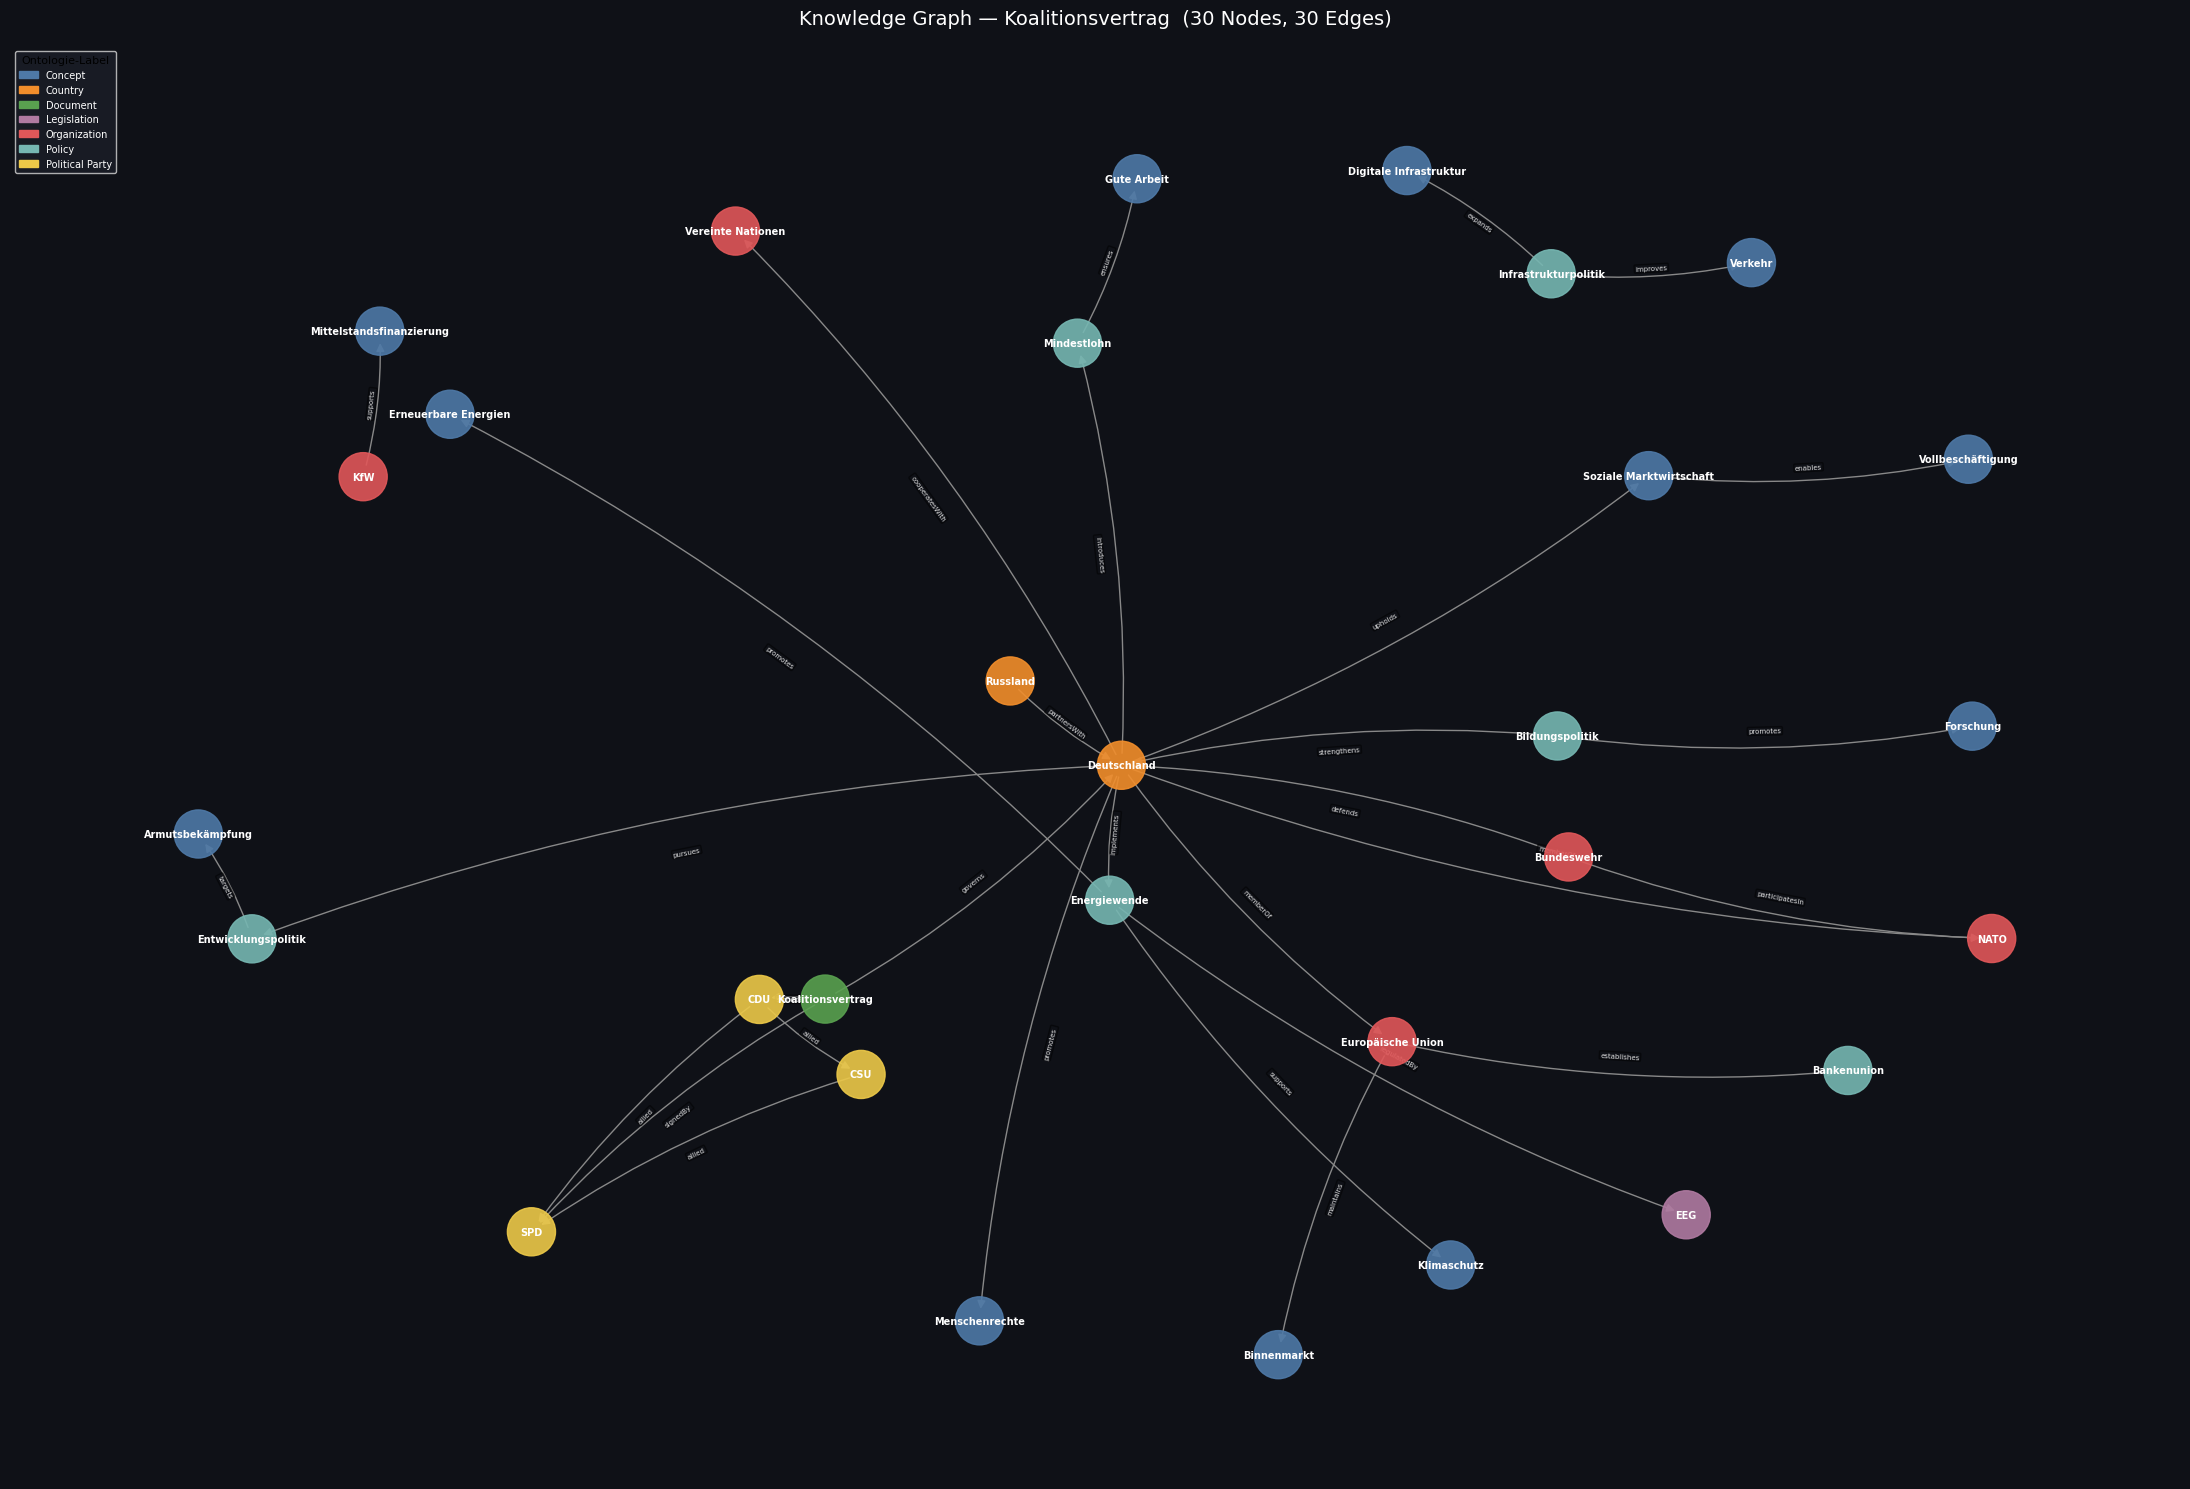

Gespeichert → knowledge_graph_static.png


In [56]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random

# ── Farb-Palette: automatisch aus allen vorhandenen Labels generiert ──────────
all_labels = sorted({G.nodes[n].get("label", "unknown") for n in G.nodes})
palette = [
    "#4E79A7","#F28E2B","#59A14F","#B07AA1","#E15759",
    "#76B7B2","#EDC948","#FF9DA7","#9C755F","#BAB0AC",
    "#D37295","#A0CBE8","#FFBE7D","#8CD17D","#86BCB6",
]
label_color = {lbl: palette[i % len(palette)] for i, lbl in enumerate(all_labels)}

# ── Subgraph: nur Nodes mit Mindestgrad (verhindert unlesbare Hairball-Graphen) ─
MIN_DEGREE = 1   # <── anpassen: 1 = alle, 3 = nur gut vernetzte Nodes
core_nodes = [n for n, d in G.degree() if d >= MIN_DEGREE]
H = G.subgraph(core_nodes).copy()
print(f"Dargestellte Nodes (Grad ≥ {MIN_DEGREE}): {H.number_of_nodes()} / {G.number_of_nodes()}")

# ── Layout ────────────────────────────────────────────────────────────────────
random.seed(42)
k_val = 3.0 / (H.number_of_nodes() ** 0.5 + 1)
pos = nx.spring_layout(H, seed=42, k=k_val, iterations=60)

# ── Zeichnen ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 15), facecolor="#0F1117")
ax.set_facecolor("#0F1117")

node_colors = [label_color.get(H.nodes[n].get("label", "unknown"), "#9C755F") for n in H.nodes]
node_labels = {n: n for n in H.nodes}  # Node-Name als Label

nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=1200, alpha=0.90, ax=ax)
nx.draw_networkx_labels(H, pos, labels=node_labels, font_size=7,
                        font_color="white", font_weight="bold", ax=ax)
nx.draw_networkx_edges(H, pos, edge_color="#888888", arrows=True,
                       arrowstyle="-|>", arrowsize=12,
                       connectionstyle="arc3,rad=0.08", ax=ax)
edge_labels = {(u, v): d["relationship"] for u, v, d in H.edges(data=True)}
nx.draw_networkx_edge_labels(H, pos, edge_labels=edge_labels, font_size=5,
                             font_color="#DDDDDD",
                             bbox=dict(boxstyle="round,pad=0.15", fc="#0F1117", alpha=0.5),
                             ax=ax)

# ── Legende ───────────────────────────────────────────────────────────────────
present_labels = sorted({H.nodes[n].get("label", "unknown") for n in H.nodes})
legend_handles = [mpatches.Patch(color=label_color[lbl], label=lbl) for lbl in present_labels]
ax.legend(handles=legend_handles, loc="upper left", facecolor="#1A1D27",
          labelcolor="white", fontsize=7, framealpha=0.85,
          title="Ontologie-Label", title_fontsize=8)

ax.set_title(f"Knowledge Graph — Koalitionsvertrag  ({H.number_of_nodes()} Nodes, {H.number_of_edges()} Edges)",
             color="white", fontsize=14, pad=16)
ax.axis("off")
plt.tight_layout()
plt.savefig("knowledge_graph_static.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Gespeichert → knowledge_graph_static.png")


## 10. Visualisierung — Interaktiv (PyVis HTML)

Erzeugt eine interaktive HTML-Datei. Öffne `knowledge_graph_interactive.html` im Browser
für Zoom, Drag & Hover-Tooltips. In JupyterLab wird die Datei direkt verlinkt.


In [ ]:
from pyvis.network import Network
from IPython.display import display, HTML

OUTPUT_HTML = "knowledge_graph_interactive.html"

net = Network(
    height="750px", width="100%",
    bgcolor="#0F1117", font_color="white",
    directed=True, notebook=False,
)

net.set_options("""
{
  "physics": {
    "forceAtlas2Based": {
      "gravitationalConstant": -80,
      "centralGravity": 0.01,
      "springLength": 200,
      "springConstant": 0.08
    },
    "maxVelocity": 50,
    "solver": "forceAtlas2Based",
    "timestep": 0.35,
    "stabilization": {"iterations": 150}
  },
  "edges": {
    "arrows": {"to": {"enabled": true, "scaleFactor": 0.7}},
    "color":  {"color": "#888888", "highlight": "#FFFFFF"},
    "smooth": {"type": "dynamic"}
  },
  "interaction": {"hover": true, "tooltipDelay": 100}
}
""")

for node_id, attrs in H.nodes(data=True):
    color = label_color.get(attrs.get("label", "unknown"), "#9C755F")
    net.add_node(
        node_id,
        label=node_id,
        title=f"<b>{node_id}</b><br>Label: {attrs.get('label', 'unknown')}",
        color=color,
        size=20,
        font={"size": 12, "color": "white"},
    )

for src, tgt, attrs in H.edges(data=True):
    net.add_edge(
        src, tgt,
        title=attrs.get("relationship", ""),
        label=attrs.get("relationship", ""),
        width=1.5,
        font={"size": 8, "color": "#CCCCCC", "align": "middle"},
    )

net.save_graph(OUTPUT_HTML)
print(f"Interaktiver Graph gespeichert → {OUTPUT_HTML}")
display(HTML(f'<a href="{OUTPUT_HTML}" target="_blank">⬡ Interaktiven Graph öffnen</a>'))


## 11. Graph-Statistiken


In [ ]:
import pandas as pd

# Top nodes by degree
degree_series = pd.Series(dict(G.degree())).sort_values(ascending=False)
print("=" * 50)
print(f"  Nodes gesamt : {G.number_of_nodes()}")
print(f"  Edges gesamt : {G.number_of_edges()}")
print(f"  Graph-Dichte : {nx.density(G):.5f}")
print()
print("  Top-10 Nodes nach Vernetzungsgrad:")
for node, deg in degree_series.head(10).items():
    print(f"    {node:<45} {deg} Verbindungen")

# Relationship type distribution
print()
rel_counts = pd.Series(
    [d["relationship"] for _, _, d in G.edges(data=True)]
).value_counts()
print("  Top-15 Relationstypen:")
print(rel_counts.head(15).to_string())
print("=" * 50)
